## Yêu cầu bài tập

### Phần 1. Tiền xử lý dữ liệu

Thực hiện các yêu cầu sau:

- Chuẩn hóa dữ liệu về khoảng `[0, 1]` hoặc dùng chuẩn hóa z-score.
- Tạo các chuỗi con với độ dài `seq_length = 20`.
- Chia dữ liệu theo tỉ lệ:
  - 70% cho tập huấn luyện
  - 15% cho tập validation
  - 15% cho tập kiểm tra

### Phần 2. Xây dựng mô hình RNN

Xây dựng mô hình RNN bằng PyTorch với cấu hình gợi ý như sau:

- `input_size = 3`
- `hidden_size = 32`
- `output_size = 1`

Yêu cầu trong quá trình huấn luyện:

- Sử dụng hàm mất mát `MSELoss`.
- Sử dụng bộ tối ưu `Adam`.
- Huấn luyện mô hình trong `150 epochs`.
- Lưu lại các giá trị sau:
  - `train loss`
  - `validation loss`

### Phần 3. Đánh giá mô hình

Sau khi huấn luyện xong, thực hiện các yêu cầu sau:

- Dự đoán trên tập test.
- Tính các chỉ số đánh giá:
  - `MSE`
  - `MAE`
- Vẽ biểu đồ so sánh:
  - giá trị thực
  - giá trị dự đoán

  ### Phần 4. Yêu cầu nâng cao

- Thử ít nhất **2 giá trị khác nhau của `seq_length`** (ví dụ: 10, 20, 30) và nhận xét xem độ dài chuỗi ảnh hưởng như thế nào đến kết quả dự đoán.
- Thay đổi số lượng **hidden_size** (ví dụ: 16, 32, 64) để so sánh hiệu quả của mô hình.
- Tăng số epoch huấn luyện và quan sát sự thay đổi của `train loss` và `validation loss`.
- Thử dự đoán **nhiều bước tiếp theo** (ví dụ: 3 bước hoặc 5 bước) thay vì chỉ dự đoán 1 bước.
- Sử dụng **dropout** hoặc tăng số tầng của mô hình RNN để kiểm tra xem mô hình có cải thiện hay không.
- Thay đổi **learning rate** của bộ tối ưu Adam và so sánh kết quả.
- Vẽ thêm biểu đồ thể hiện sai số dự đoán theo từng thời điểm trên tập test.
- Viết phần nhận xét ngắn về những yếu tố làm mô hình dự đoán tốt hơn hoặc kém hơn.

Deadline: 28/03/2026


In [6]:
# ===== Phần 1: Tiền xử lý dữ liệu =====
import torch
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Nếu df chưa tồn tại (chạy cell độc lập), tạo dữ liệu mẫu
if 'df' not in globals():
    time_steps = 300
    t = np.linspace(0, 30, time_steps)
    feature_1 = np.sin(t)
    feature_2 = np.cos(0.5 * t)
    feature_3 = 0.05 * t + 0.1 * np.random.randn(time_steps)
    target = 0.5 * feature_1 + 0.3 * feature_2 + 0.2 * feature_3 + 0.05 * np.random.randn(time_steps)
    df = pd.DataFrame({'feature_1': feature_1, 'feature_2': feature_2, 'feature_3': feature_3, 'target': target})

# Chuẩn hóa dữ liệu về [0,1] với MinMaxScaler
scaler = MinMaxScaler()
columns = ['feature_1','feature_2','feature_3','target']
scaled = scaler.fit_transform(df[columns])
df_scaled = pd.DataFrame(scaled, columns=columns)

# Hàm tạo chuỗi con
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length, :-1])  # 3 đặc trưng
        y.append(data[i + seq_length, -1])     # target
    return np.array(X), np.array(y)

# Dùng seq_length = 20 (phần 2 quy định)
seq_length_default = 20
X_all, y_all = create_sequences(df_scaled.values, seq_length_default)

# Chia dữ liệu 70/15/15
n = len(X_all)
train_end = int(0.7*n)
val_end = int(0.85*n)

X_train, y_train = X_all[:train_end], y_all[:train_end]
X_val, y_val = X_all[train_end:val_end], y_all[train_end:val_end]
X_test, y_test = X_all[val_end:], y_all[val_end:]

# Chuyển sang tensor
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train).unsqueeze(1)
X_val_t = torch.FloatTensor(X_val)
y_val_t = torch.FloatTensor(y_val).unsqueeze(1)
X_test_t = torch.FloatTensor(X_test)
y_test_t = torch.FloatTensor(y_test).unsqueeze(1)

print('Shapes:', X_train_t.shape, X_val_t.shape, X_test_t.shape)

Shapes: torch.Size([196, 20, 3]) torch.Size([42, 20, 3]) torch.Size([42, 20, 3])


Epoch 1/150 - Train MSE: 0.135028, Val MSE: 0.072153
Epoch 25/150 - Train MSE: 0.002081, Val MSE: 0.001829
Epoch 50/150 - Train MSE: 0.001409, Val MSE: 0.001248
Epoch 75/150 - Train MSE: 0.001213, Val MSE: 0.001323
Epoch 100/150 - Train MSE: 0.001293, Val MSE: 0.001333
Epoch 125/150 - Train MSE: 0.001221, Val MSE: 0.001362
Epoch 150/150 - Train MSE: 0.001132, Val MSE: 0.001241


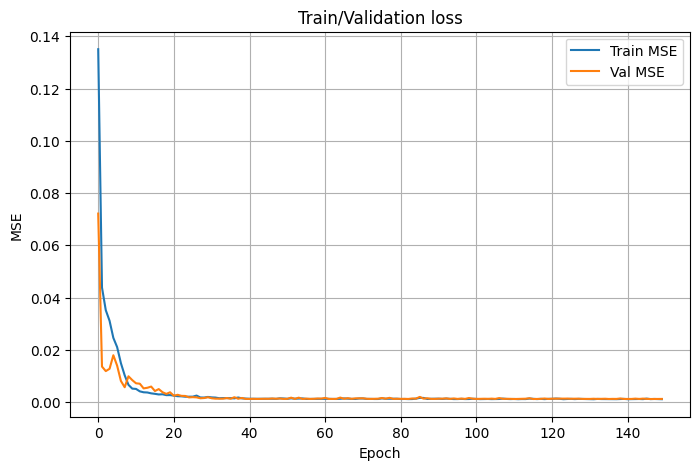

In [9]:
# ===== Phần 2: Xây dựng mô hình RNN =====
import torch.nn as nn
import matplotlib.pyplot as plt


class RNNModel(nn.Module):
    def __init__(self, input_size=3, hidden_size=32, output_size=1,
                 n_layers=1, dropout=0.0):
        super().__init__()
        self.hidden_size = hidden_size
        self.n_layers = n_layers
        self.rnn = nn.RNN(input_size, hidden_size, num_layers=n_layers,
                          batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x, hidden):
        out, hidden = self.rnn(x, hidden)
        out = self.fc(out[:, -1, :])
        return out, hidden

    def init_hidden(self, batch_size):
        return torch.zeros(self.n_layers, batch_size, self.hidden_size)

# Khởi tạo mô hình mặc định
model = RNNModel(input_size=3, hidden_size=32, output_size=1)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Huấn luyện
num_epochs = 150
batch_size = 32
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    perm = np.random.permutation(len(X_train_t))
    epoch_loss = 0.0
    for i in range(0, len(X_train_t), batch_size):
        ids = perm[i:i+batch_size]
        bx = X_train_t[ids]
        by = y_train_t[ids]
        h0 = model.init_hidden(len(bx))
        optimizer.zero_grad()
        out, _ = model(bx, h0)
        loss = criterion(out, by)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(bx)

    epoch_loss /= len(X_train_t)
    train_losses.append(epoch_loss)

    model.eval()
    with torch.no_grad():
        hval = model.init_hidden(len(X_val_t))
        out_val, _ = model(X_val_t, hval)
        val_loss = criterion(out_val, y_val_t).item()
        val_losses.append(val_loss)

    if (epoch+1) % 25 == 0 or epoch == 0:
        print(f'Epoch {epoch+1}/{num_epochs} - Train MSE: {epoch_loss:.6f}, Val MSE: {val_loss:.6f}')

# Vẽ loss
plt.figure(figsize=(8,5))
plt.plot(train_losses, label='Train MSE')
plt.plot(val_losses, label='Val MSE')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Train/Validation loss')
plt.legend()
plt.grid(True)
plt.show()

Test MSE=0.001319, Test MAE=0.029665


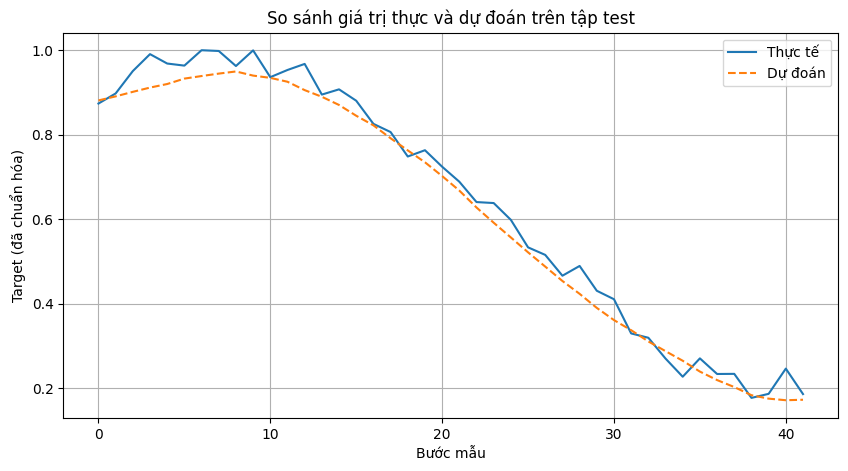

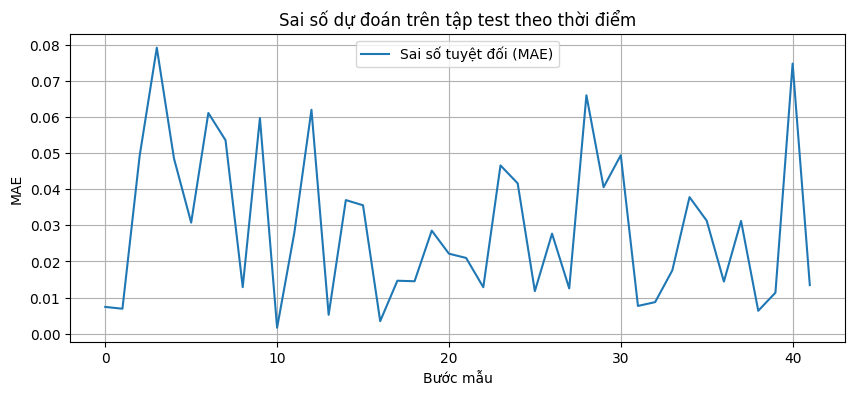

In [10]:
# ===== Phần 3: Đánh giá mô hình =====
model.eval()
with torch.no_grad():
    htest = model.init_hidden(len(X_test_t))
    preds_test, _ = model(X_test_t, htest)

mse_test = mean_squared_error(y_test_t.numpy(), preds_test.numpy())
mae_test = mean_absolute_error(y_test_t.numpy(), preds_test.numpy())
print(f'Test MSE={mse_test:.6f}, Test MAE={mae_test:.6f}')

plt.figure(figsize=(10,5))
plt.plot(y_test, label='Thực tế')
plt.plot(preds_test.numpy().flatten(), label='Dự đoán', linestyle='--')
plt.title('So sánh giá trị thực và dự đoán trên tập test')
plt.xlabel('Bước mẫu')
plt.ylabel('Target (đã chuẩn hóa)')
plt.legend()
plt.grid(True)
plt.show()

# Sai số theo thời điểm
errors = np.abs(y_test - preds_test.numpy().flatten())
plt.figure(figsize=(10,4))
plt.plot(errors, label='Sai số tuyệt đối (MAE)')
plt.title('Sai số dự đoán trên tập test theo thời điểm')
plt.xlabel('Bước mẫu')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
# ===== Phần 4: Thử nghiệm nâng cao =====
print('\n===== Thử nghiệm nâng cao =====')

# A. seq_length khác nhau
for seq_length in [10, 20, 30]:
    X_tmp, y_tmp = create_sequences(df_scaled.values, seq_length)
    n_tmp = len(X_tmp)
    train_end_tmp = int(0.7*n_tmp)
    val_end_tmp = int(0.85*n_tmp)
    X_train_tmp = torch.FloatTensor(X_tmp[:train_end_tmp])
    y_train_tmp = torch.FloatTensor(y_tmp[:train_end_tmp]).unsqueeze(1)
    X_val_tmp = torch.FloatTensor(X_tmp[train_end_tmp:val_end_tmp])
    y_val_tmp = torch.FloatTensor(y_tmp[train_end_tmp:val_end_tmp]).unsqueeze(1)

    model_tmp = RNNModel(input_size=3, hidden_size=32, output_size=1)
    opt_tmp = torch.optim.Adam(model_tmp.parameters(), lr=0.001)
    for ep in range(30):
        model_tmp.train()
        h = model_tmp.init_hidden(len(X_train_tmp))
        out_tmp, _ = model_tmp(X_train_tmp, h)
        loss_tmp = criterion(out_tmp, y_train_tmp)
        opt_tmp.zero_grad(); loss_tmp.backward(); opt_tmp.step()

    model_tmp.eval()
    with torch.no_grad():
        h2 = model_tmp.init_hidden(len(X_val_tmp))
        vpred, _ = model_tmp(X_val_tmp, h2)
    v_mse = mean_squared_error(y_val_tmp.numpy(), vpred.numpy())
    print(f'seq_length={seq_length}, val MSE={v_mse:.6f}')

# B. hidden_size khác nhau
for hidden_size in [16, 32, 64]:
    model_h = RNNModel(input_size=3, hidden_size=hidden_size, output_size=1)
    opt_h = torch.optim.Adam(model_h.parameters(), lr=0.001)
    for ep in range(30):
        model_h.train()
        h = model_h.init_hidden(len(X_train_t))
        out_h, _ = model_h(X_train_t, h)
        loss_h = criterion(out_h, y_train_t)
        opt_h.zero_grad(); loss_h.backward(); opt_h.step()

    model_h.eval()
    with torch.no_grad():
        h2 = model_h.init_hidden(len(X_val_t))
        vpred_h, _ = model_h(X_val_t, h2)
    print(f'hidden_size={hidden_size}, val MSE={mean_squared_error(y_val_t.numpy(), vpred_h.numpy()):.6f}')

# C. n_layers và dropout
model_dropout = RNNModel(input_size=3, hidden_size=32, output_size=1, n_layers=2, dropout=0.2)
opt_do = torch.optim.Adam(model_dropout.parameters(), lr=0.001)
for ep in range(50):
    model_dropout.train(); h = model_dropout.init_hidden(len(X_train_t))
    out_do, _ = model_dropout(X_train_t, h)
    loss_do = criterion(out_do, y_train_t)
    opt_do.zero_grad(); loss_do.backward(); opt_do.step()

model_dropout.eval();
with torch.no_grad():
    h_val_do = model_dropout.init_hidden(len(X_val_t))
    vpred_do, _ = model_dropout(X_val_t, h_val_do)
print('RNN 2 lớp + dropout 0.2, val MSE:', mean_squared_error(y_val_t.numpy(), vpred_do.numpy()))

# D. thử predict nhiều bước tiếp theo (3 và 5)
for n_step in [3, 5]:
    input_seq = X_test_t[:1].clone()
    pred_multi = []
    with torch.no_grad():
        h = model.init_hidden(1)
        seq = input_seq.clone()
        for _ in range(n_step):
            out, h = model(seq, h)
            pred = out.item()
            pred_multi.append(pred)
            # Giả sử tiếp theo lấy giá trị target dự đoán cho cả 3 đặc trưng để duy trì shape [1, seq_length, 3]
            next_step = torch.tensor([[[pred, pred, pred]]], dtype=torch.float32)
            seq = torch.cat((seq[:, 1:, :], next_step), dim=1)
    print(f'Predict {n_step} bước tiếp theo (chuỗi bắt đầu mẫu 1):', np.round(pred_multi, 4))

# E. learning rate khác nhau
for lr in [0.0005, 0.001, 0.005]:
    model_lr = RNNModel(input_size=3, hidden_size=32, output_size=1)
    opt_lr = torch.optim.Adam(model_lr.parameters(), lr=lr)
    for ep in range(30):
        model_lr.train(); h = model_lr.init_hidden(len(X_train_t))
        out_lr, _ = model_lr(X_train_t, h)
        loss_lr = criterion(out_lr, y_train_t)
        opt_lr.zero_grad(); loss_lr.backward(); opt_lr.step()
    model_lr.eval();
    with torch.no_grad():
        h_val_lr = model_lr.init_hidden(len(X_val_t))
        pred_lr, _ = model_lr(X_val_t, h_val_lr)
    print(f'lr={lr}, val MSE={mean_squared_error(y_val_t.numpy(), pred_lr.numpy()):.6f}')

print('\nHoàn thành tất cả phần 1-4.')


===== Thử nghiệm nâng cao =====
seq_length=10, val MSE=0.009073
seq_length=20, val MSE=0.019828
seq_length=30, val MSE=0.036635
hidden_size=16, val MSE=0.017642
hidden_size=32, val MSE=0.019294
hidden_size=64, val MSE=0.008902
RNN 2 lớp + dropout 0.2, val MSE: 0.016126828268170357
Predict 3 bước tiếp theo (chuỗi bắt đầu mẫu 1): [0.8812 0.9054 0.9114]
Predict 5 bước tiếp theo (chuỗi bắt đầu mẫu 1): [0.8812 0.9054 0.9114 0.9172 0.9247]
lr=0.0005, val MSE=0.044032
lr=0.001, val MSE=0.019810
lr=0.005, val MSE=0.004527

Hoàn thành tất cả phần 1-4.
